1D CONVECTION-DOMINATED PROBLEM
epsilon = 0.01
b       = 1.0
N       = 50
h       = 0.020000
------------------------------------------------------------
Central Difference Errors:
  L2 error      = 1.931702e-02
  Linf error    = 1.353353e-01
------------------------------------------------------------
Upwind Difference Errors:
  L2 error      = 3.135966e-02
  Linf error    = 1.979981e-01


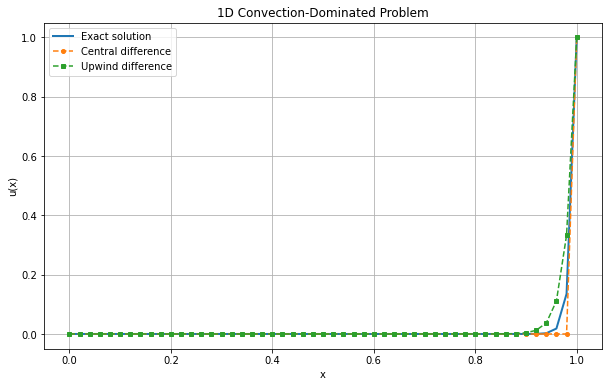

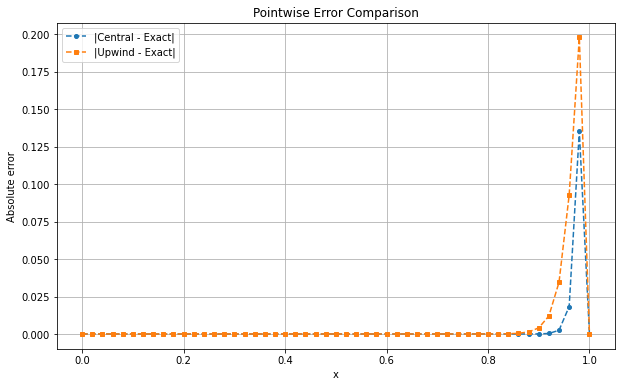


Mesh refinement study:
------------------------------------------------------------
       N            h         Central L2          Upwind L2
------------------------------------------------------------
      10 1.000000e-01       2.907803e-01       2.885322e-02
      20 5.000000e-02       1.074254e-01       3.631000e-02
      40 2.500000e-02       3.056137e-02       3.451099e-02
      80 1.250000e-02       7.142093e-03       2.338480e-02
     160 6.250000e-03       1.678348e-03       1.339502e-02


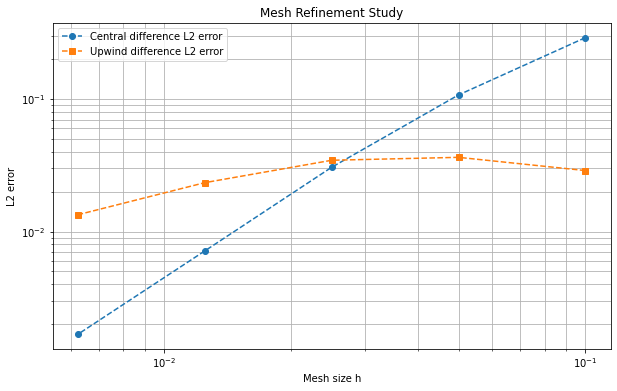

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# 1. Problem setup


epsilon = 0.01   # diffusion coefficient (small => convection-dominated)
b = 1.0          # convection coefficient
a = 0.0          # left boundary of domain
c = 1.0          # right boundary of domain

ua = 0.0         # u(0)
uc = 1.0         # u(1)

N = 50           # number of subintervals



#2.Exact solution

# For
#    -epsilon u'' + b u' = 0,  x in (0,1)
#    u(0)=0, u(1)=1
#
# the exact solution is
#    u(x) = (exp((b/epsilon)x) - 1)/(exp(b/epsilon) - 1)
#
# This develops a boundary layer near x = 1 when epsilon is very small.


def exact_solution(x, epsilon, b):
    # stable evaluation for moderate parameters
    numerator = np.exp((b / epsilon) * x) - 1.0
    denominator = np.exp(b / epsilon) - 1.0
    return numerator / denominator



#3.Central difference method

# Approximation:
#   u''(x_i) ~ (u_{i+1} - 2u_i + u_{i-1}) / h^2
#   u'(x_i)  ~ (u_{i+1} - u_{i-1}) / (2h)
#
# Then
#   -epsilon*u'' + b*u' = 0
#
# gives
#   (-epsilon/h^2 - b/(2h)) u_{i-1}
# + ( 2epsilon/h^2 )        u_i
# + (-epsilon/h^2 + b/(2h)) u_{i+1}
# = 0


def solve_central_difference(epsilon, b, a, c, ua, uc, N):
    h = (c - a) / N
    x = np.linspace(a, c, N + 1)

    # number of interior points
    m = N - 1

    A = np.zeros((m, m))
    rhs = np.zeros(m)

    lower = -epsilon / h**2 - b / (2.0 * h)
    diag  =  2.0 * epsilon / h**2
    upper = -epsilon / h**2 + b / (2.0 * h)

    for i in range(m):
        A[i, i] = diag
        if i > 0:
            A[i, i - 1] = lower
        if i < m - 1:
            A[i, i + 1] = upper

    # Incorporate boundary conditions
    rhs[0]  -= lower * ua
    rhs[-1] -= upper * uc

    u_interior = np.linalg.solve(A, rhs)

    u = np.zeros(N + 1)
    u[0] = ua
    u[-1] = uc
    u[1:N] = u_interior

    return x, u



#4.Upwind difference method

# For b > 0, use backward difference for u':
#   u'(x_i) ~ (u_i - u_{i-1}) / h
#
# Then
#   -epsilon*u'' + b*u' = 0
#
# gives
#   (-epsilon/h^2 - b/h) u_{i-1}
# + ( 2epsilon/h^2 + b/h ) u_i
# + (-epsilon/h^2) u_{i+1}
# = 0


def solve_upwind_difference(epsilon, b, a, c, ua, uc, N):
    h = (c - a) / N
    x = np.linspace(a, c, N + 1)

    m = N - 1

    A = np.zeros((m, m))
    rhs = np.zeros(m)

    lower = -epsilon / h**2 - b / h
    diag  =  2.0 * epsilon / h**2 + b / h
    upper = -epsilon / h**2

    for i in range(m):
        A[i, i] = diag
        if i > 0:
            A[i, i - 1] = lower
        if i < m - 1:
            A[i, i + 1] = upper

    # Incorporate boundary conditions
    rhs[0]  -= lower * ua
    rhs[-1] -= upper * uc

    u_interior = np.linalg.solve(A, rhs)

    u = np.zeros(N + 1)
    u[0] = ua
    u[-1] = uc
    u[1:N] = u_interior

    return x, u



# 5.Error norms

def compute_errors(u_num, u_ex, h):
    err = u_num - u_ex
    l_inf = np.max(np.abs(err))
    l2 = np.sqrt(h * np.sum(err**2))
    return l2, l_inf



#Run the methods

x = np.linspace(a, c, N + 1)
u_exact = exact_solution(x, epsilon, b)

x_c, u_central = solve_central_difference(epsilon, b, a, c, ua, uc, N)
x_u, u_upwind  = solve_upwind_difference(epsilon, b, a, c, ua, uc, N)

h = (c - a) / N

l2_c, linf_c = compute_errors(u_central, u_exact, h)
l2_u, linf_u = compute_errors(u_upwind, u_exact, h)



print("=" * 60)
print("1D CONVECTION-DOMINATED PROBLEM")
print("=" * 60)
print(f"epsilon = {epsilon}")
print(f"b       = {b}")
print(f"N       = {N}")
print(f"h       = {h:.6f}")
print("-" * 60)
print("Central Difference Errors:")
print(f"  L2 error      = {l2_c:.6e}")
print(f"  Linf error    = {linf_c:.6e}")
print("-" * 60)
print("Upwind Difference Errors:")
print(f"  L2 error      = {l2_u:.6e}")
print(f"  Linf error    = {linf_u:.6e}")
print("=" * 60)



# 8. Plot numerical solutions against exact solution


plt.figure(figsize=(10, 6))
plt.plot(x, u_exact, label="Exact solution", linewidth=2)
plt.plot(x_c, u_central, "o--", label="Central difference", markersize=4)
plt.plot(x_u, u_upwind, "s--", label="Upwind difference", markersize=4)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("1D Convection-Dominated Problem")
plt.legend()
plt.grid(True)
plt.show()



# 9. Plot pointwise errors


plt.figure(figsize=(10, 6))
plt.plot(x, np.abs(u_central - u_exact), "o--", label="|Central - Exact|", markersize=4)
plt.plot(x, np.abs(u_upwind - u_exact), "s--", label="|Upwind - Exact|", markersize=4)
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title("Pointwise Error Comparison")
plt.legend()
plt.grid(True)
plt.show()



# 10. Optional mesh study

# This helps you show in your report how errors behave as N changes.

mesh_values = [10, 20, 40, 80, 160]
central_l2_errors = []
upwind_l2_errors = []
hs = []

for N_test in mesh_values:
    h_test = (c - a) / N_test
    x_test = np.linspace(a, c, N_test + 1)
    u_ex_test = exact_solution(x_test, epsilon, b)

    _, u_c_test = solve_central_difference(epsilon, b, a, c, ua, uc, N_test)
    _, u_u_test = solve_upwind_difference(epsilon, b, a, c, ua, uc, N_test)

    l2_c_test, _ = compute_errors(u_c_test, u_ex_test, h_test)
    l2_u_test, _ = compute_errors(u_u_test, u_ex_test, h_test)

    hs.append(h_test)
    central_l2_errors.append(l2_c_test)
    upwind_l2_errors.append(l2_u_test)

print("\nMesh refinement study:")
print("-" * 60)
print(f"{'N':>8} {'h':>12} {'Central L2':>18} {'Upwind L2':>18}")
print("-" * 60)
for N_test, h_test, ec, eu in zip(mesh_values, hs, central_l2_errors, upwind_l2_errors):
    print(f"{N_test:8d} {h_test:12.6e} {ec:18.6e} {eu:18.6e}")

plt.figure(figsize=(10, 6))
plt.loglog(hs, central_l2_errors, "o--", label="Central difference L2 error")
plt.loglog(hs, upwind_l2_errors, "s--", label="Upwind difference L2 error")
plt.xlabel("Mesh size h")
plt.ylabel("L2 error")
plt.title("Mesh Refinement Study")
plt.legend()
plt.grid(True, which="both")
plt.show()